# 03. 분기와 병렬 실행 (Branching & Parallel Execution)

> LangGraph의 superstep 모델은 노드 병렬 실행을 자연스럽게 지원해요. Fan-out/Fan-in과 리듀서, 동적 분기를 묶어 병렬 워크로드의 정석을 배워요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. Fan-out / Fan-in 패턴으로 노드를 병렬 실행하고 결과를 하나로 모을 수 있어요
2. `Annotated[list, operator.add]` 리듀서(Reducer)로 여러 노드의 결과를 안전하게 병합할 수 있어요
3. `add_conditional_edges()`로 런타임 상태에 따른 동적 분기를 구성할 수 있어요
4. 커스텀 리듀서(Custom Reducer)로 병렬 결과를 신뢰도 기반으로 정렬·집계할 수 있어요
5. Superstep 트랜잭션 특성을 이해하고 병렬 실행 중 예외를 올바르게 처리할 수 있어요

## 사전 지식

- `02-Subgraphs.ipynb` — 서브그래프 구성, 부모-자식 상태 변환
- LangGraph 기초: `StateGraph`, `add_node`, `add_edge`, `compile`, `invoke`
- Python `TypedDict`, `Annotated` 타입 힌트 기본 이해

## 핵심 개념: Fan-out / Fan-in

**Fan-out**은 하나의 노드에서 여러 노드로 동시에 분기하는 패턴이에요. **Fan-in**은 반대로 여러 노드의 결과를 하나의 노드로 모으는 패턴이에요.

피자를 만드는 과정을 예로 들어볼게요:
- Fan-out: 도우 준비, 소스 준비, 치즈 준비를 **동시에** 시작해요
- Fan-in: 준비된 재료를 모두 **합쳐서** 완성 피자를 만들어요

이 패턴을 LangGraph에서 구현하면 **전체 처리 시간을 크게 단축**할 수 있어요!

```mermaid
flowchart LR
    S([시작<br>START]) --> A[노드 A<br>Fan-out 시작]
    A --> B[노드 B<br>병렬 실행]
    A --> C[노드 C<br>병렬 실행]
    B --> D[노드 D<br>Fan-in 집결]
    C --> D
    D --> E([끝<br>END])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef parallel fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class S input
    class A process
    class B,C parallel
    class D,E output
```

### 핵심 구성 요소

| 구성 요소 | 역할 | 예시 |
|-----------|------|------|
| `add_edge("a", "b")` + `add_edge("a", "c")` | Fan-out: 하나에서 여러 개로 분기 | A → B, A → C 동시 실행 |
| `add_edge(["b", "c"], "d")` | Fan-in: 여러 개를 하나로 모음 | B, C 완료 후 D 실행 |
| `Annotated[list, operator.add]` | 병렬 결과를 안전하게 누적 | 각 노드의 리스트를 합쳐요 |
| `add_conditional_edges()` | 런타임 상태에 따른 동적 분기 | 상태 값으로 경로 선택 |
| `defer=True` | 모든 선행 작업 완료 대기 | 명시적 의존성 없이 동기화 |

> 🔑 **핵심 개념**: `operator.add` 리듀서는 여러 병렬 노드가 같은 상태 키에 쓸 때 값을 덮어쓰지 않고 **리스트를 연결(concatenate)**해요. 병렬 실행에서 상태 충돌을 방지하는 핵심 메커니즘이에요.

## 환경 설정

In [1]:
# 환경 변수 로드 (.env 파일에서 API 키를 읽어요)
from dotenv import load_dotenv

load_dotenv(override=True)

True

In [2]:
import os

# LangSmith 추적 설정 (실행 흐름을 시각화해서 확인할 수 있어요)
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-Branching-Parallel"

## 1. 기본 Fan-out / Fan-in

가장 단순한 형태의 병렬 실행 패턴을 살펴볼게요. 노드 A에서 B와 C로 팬아웃하고, B와 C의 결과를 D에서 팬인하는 구조예요.

### 왜 리듀서(Reducer)가 필요한가요?

병렬 노드 B와 C가 같은 상태 키 `aggregate`에 동시에 값을 쓰면 어떻게 될까요? 기본 동작은 **마지막으로 쓴 값이 이전 값을 덮어씁니다**. 이건 우리가 원하는 동작이 아니에요!

마치 두 사람이 같은 문서에 동시에 쓰면 한 사람의 내용이 사라지는 것과 같아요. `Annotated[list, operator.add]`를 사용하면 각 노드의 출력이 **기존 리스트에 누적**되어 모든 결과를 보존할 수 있어요.

| reducer 없을 때 | `operator.add` reducer 사용 |
|:---|:---|
| B가 `["B"]` 쓰고 C가 `["C"]` 쓰면 | B가 `["B"]` 쓰고 C가 `["C"]` 쓰면 |
| 최종: `["C"]` (B 결과 유실!) | 최종: `["B", "C"]` (모두 보존) |

> 🔑 **핵심 개념**: `add_messages` 리듀서는 LangChain 메시지 객체 전용이에요. 일반 데이터 리스트 누적에는 `operator.add`를 사용해요.

> 🎯 **강의 포인트**: `ReturnNodeValue` 클래스 패턴에 주목하세요. 노드 로직을 클래스로 캡슐화하면 각 노드에 서로 다른 값을 주입할 수 있어요. 함수 대신 클래스를 사용하는 이유를 학생들에게 질문해보세요!

In [3]:
import operator
from typing import Annotated, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# ---------------------------------------------------
# 상태 정의: operator.add 리듀서로 리스트 누적
# ---------------------------------------------------
# aggregate 키에 여러 노드가 쓸 때 덮어쓰지 않고 리스트를 연결해요
class State(TypedDict):
    aggregate: Annotated[list, operator.add]


# ---------------------------------------------------
# ReturnNodeValue: 노드 로직을 클래스로 캡슐화
# ---------------------------------------------------
# 각 노드마다 다른 값을 반환하도록 node_secret을 주입해요
class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret  # 이 노드가 반환할 고유 값

    def __call__(self, state: State) -> Any:
        # 현재 집계 상태를 출력하고 새 값을 추가해요
        print(f"Adding {self._value} to {state['aggregate']}")
        return {"aggregate": [self._value]}  # 리스트로 반환: reducer가 누적해요


# ---------------------------------------------------
# 그래프 구성: A → (B, C 병렬) → D
# ---------------------------------------------------
builder = StateGraph(State)

# 노드 추가: 각 노드는 서로 다른 값을 반환해요
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# 엣지 연결
builder.add_edge(START, "a")  # 시작 → A
builder.add_edge("a", "b")    # A → B (fan-out 시작)
builder.add_edge("a", "c")    # A → C (B와 동시에 실행!)
builder.add_edge("b", "d")    # B → D (fan-in을 향해)
builder.add_edge("c", "d")    # C → D (B, C 모두 완료 후 D 실행)
builder.add_edge("d", END)    # D → 종료

# 그래프 컴파일
graph = builder.compile()
# 그래프 컴파일 완료!

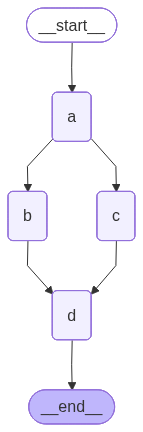

In [4]:
# 그래프 흐름: START → a → (b, c 병렬) → d → END
# a 노드: Fan-out 시작점, "I'm A"를 aggregate에 추가해요
# b, c 노드: 동일 Superstep에서 병렬 실행돼요
# d 노드: Fan-in 지점, b와 c 모두 완료 후 실행돼요
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
# 그래프 실행: 빈 리스트에서 시작해서 각 노드가 값을 누적해요
result = graph.invoke({"aggregate": []})
print("\n최종 결과:", result)

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm D to ["I'm A", "I'm B", "I'm C"]

최종 결과: {'aggregate': ["I'm A", "I'm B", "I'm C", "I'm D"]}


실행 결과를 보면 B와 C가 병렬로 실행될 때 둘 다 `["I'm A"]` 상태를 보고 있어요. 이건 B와 C가 **같은 superstep**에서 동시에 실행되기 때문이에요.

D의 입력을 보면 B와 C의 결과가 모두 누적되어 있어요. `operator.add` 리듀서 덕분에 어느 쪽도 덮어쓰이지 않았어요!

## 2. 다단계 경로의 Fan-out / Fan-in

실제 애플리케이션에서는 하나의 병렬 경로가 여러 단계로 구성될 수 있어요. 예를 들어 `B1 → B2` 경로와 `C` 경로가 병렬로 실행된 후 `D`에서 합쳐지는 구조예요.

이런 경우 `add_edge(["b2", "c"], "d")`처럼 **리스트로 선행 노드를 명시**하면 돼요.

> 💡 **실무 팁**: 병렬 경로의 길이가 다를 때는 이 패턴이 유용해요. 짧은 경로(C)가 먼저 끝나도 긴 경로(B1→B2)가 완료될 때까지 D는 기다려요.

In [6]:
import operator
from typing import Annotated, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# ---------------------------------------------------
# 상태 및 노드 클래스 정의 (이전 섹션과 동일)
# ---------------------------------------------------
class State(TypedDict):
    aggregate: Annotated[list, operator.add]


class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state['aggregate']}")
        return {"aggregate": [self._value]}


# ---------------------------------------------------
# 다단계 경로 그래프: A → (B1→B2 || C) → D
# ---------------------------------------------------
# B 경로는 2단계(B1→B2), C 경로는 1단계 - 길이가 달라요!
builder = StateGraph(State)

builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b1", ReturnNodeValue("I'm B1"))  # B 경로 1단계
builder.add_node("b2", ReturnNodeValue("I'm B2"))  # B 경로 2단계
builder.add_node("c", ReturnNodeValue("I'm C"))    # C 경로 (1단계)
builder.add_node("d", ReturnNodeValue("I'm D"))    # Fan-in 지점

builder.add_edge(START, "a")
builder.add_edge("a", "b1")         # A → B1 (fan-out)
builder.add_edge("a", "c")          # A → C (B 경로와 병렬)
builder.add_edge("b1", "b2")        # B1 → B2 (순차 실행)
builder.add_edge(["b2", "c"], "d")  # B2와 C가 모두 완료되면 D 실행 (fan-in!)
builder.add_edge("d", END)

graph2 = builder.compile()
# 다단계 경로 그래프 컴파일 완료!

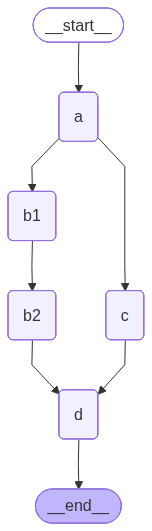

In [7]:
# 그래프 흐름: START → a → (b1 → b2 || c) → d → END
# a 노드: Fan-out 시작, 두 경로로 분기해요
# b1 → b2: 2단계 순차 경로예요
# c: 1단계 단독 경로 (b 경로와 병렬)
# d 노드: b2와 c가 모두 완료되면 실행돼요 (Fan-in)
from IPython.display import Image, display

display(Image(graph2.get_graph().draw_mermaid_png()))

In [8]:
# 그래프 실행 - C가 먼저 끝나도 B2를 기다린 후 D가 실행돼요
result2 = graph2.invoke({"aggregate": []})
print("\n최종 결과:", result2)

Adding I'm A to []
Adding I'm B1 to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B1", "I'm C"]
Adding I'm D to ["I'm A", "I'm B1", "I'm C", "I'm B2"]

최종 결과: {'aggregate': ["I'm A", "I'm B1", "I'm C", "I'm B2", "I'm D"]}


## 3. defer=True로 간편한 동기화

그래프가 복잡해지면 `add_edge(["b2", "c"], "d")`처럼 모든 선행 노드를 일일이 나열하기 어려울 수 있어요. LangGraph는 이 문제를 `defer=True` 옵션으로 해결해요.

`add_node("d", ..., defer=True)`로 설정하면 노드 D는 **현재 진행 중인 모든 대기 작업이 완료될 때까지** 자동으로 기다려요.

### 명시적 Fan-in vs defer=True

| 방법 | 코드 | 유연성 | 적합한 상황 |
|------|------|--------|------------|
| 명시적 Fan-in | `add_edge(["b2", "c"], "d")` | 특정 노드만 기다려요 | 어떤 노드를 기다릴지 명확할 때 |
| `defer=True` | `add_node("d", ..., defer=True)` | 모든 대기 작업을 자동으로 기다려요 | 조건부 분기로 실행 노드가 유동적일 때 |

> 💡 **실무 팁**: `defer=True`는 조건부 분기로 인해 어떤 노드가 실행될지 미리 알 수 없는 경우, 또는 map-reduce 패턴에서 특히 유용해요.

> ⚠️ **자주 하는 실수**: `defer=True`는 현재 그래프의 **모든 대기 작업**을 기다려요. 특정 노드만 선택적으로 기다리려면 명시적인 `add_edge([...], "d")`를 사용하세요.

In [9]:
import operator
from typing import Annotated, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# ---------------------------------------------------
# defer=True 활용: 명시적 fan-in 없이 동기화
# ---------------------------------------------------
class State(TypedDict):
    aggregate: Annotated[list, operator.add]


class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state['aggregate']}")
        return {"aggregate": [self._value]}


builder = StateGraph(State)

builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b1", ReturnNodeValue("I'm B1"))
builder.add_node("b2", ReturnNodeValue("I'm B2"))
builder.add_node("c", ReturnNodeValue("I'm C"))

# defer=True: 모든 대기 중인 작업이 완료될 때까지 실행을 자동으로 지연해요
# add_edge(["b2", "c"], "d") 없이도 동일한 동기화 효과!
builder.add_node("d", ReturnNodeValue("I'm D"), defer=True)

builder.add_edge(START, "a")
builder.add_edge("a", "b1")
builder.add_edge("a", "c")
builder.add_edge("b1", "b2")
builder.add_edge("b2", "d")  # B2에서 D로
builder.add_edge("c", "d")   # C에서 D로 - defer=True가 두 경로를 모두 기다려요
builder.add_edge("d", END)

graph3 = builder.compile()
# defer=True 그래프 컴파일 완료!

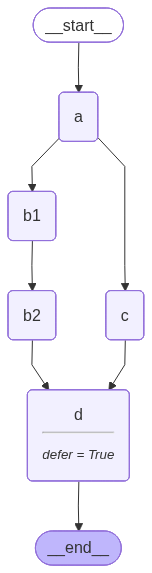

In [10]:
# 그래프 흐름: START → a → (b1 → b2 || c) → d(defer) → END
# defer=True: d 노드가 모든 대기 작업 완료를 자동으로 기다려요
# 명시적 Fan-in([b2, c], d) 없이도 동일한 동기화 효과를 얻어요
from IPython.display import Image, display

display(Image(graph3.get_graph().draw_mermaid_png()))

In [11]:
# C가 먼저 끝나도 defer=True 덕분에 B2를 기다린 후 D가 실행돼요
result3 = graph3.invoke({"aggregate": []})
print("\n최종 결과:", result3)

Adding I'm A to []
Adding I'm B1 to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B1", "I'm C"]
Adding I'm D to ["I'm A", "I'm B1", "I'm C", "I'm B2"]

최종 결과: {'aggregate': ["I'm A", "I'm B1", "I'm C", "I'm B2", "I'm D"]}


## 4. Superstep 트랜잭션과 예외 처리

### Superstep이란?

LangGraph의 병렬 실행은 **Superstep** 단위로 처리돼요. Superstep이란 동시에 실행되는 노드들의 묶음이에요. 은행 계좌이체를 생각해보세요. 출금과 입금이 **둘 다 성공하거나 둘 다 취소**되어야 하죠. Superstep도 마찬가지예요.

중요한 특성: Superstep은 **트랜잭션(Transaction)**처럼 동작해요.
- 한 Superstep 내 **어느 하나라도 실패**하면 전체 Superstep이 롤백돼요
- 상태 업데이트가 **전혀 적용되지 않아요**

```mermaid
flowchart LR
    A[노드 A] --> B[노드 B<br/>성공]
    A --> C[노드 C<br/>실패!]
    B --> D[노드 D]
    C --> D

    subgraph SS[Superstep - 트랜잭션]
        B
        C
    end

    style C fill:#f8d7da,stroke:#dc3545,color:#721c24
    style SS fill:#fff3cd,stroke:#ffc107
```

> ⚠️ **자주 하는 실수**: C 노드가 실패하면 B 노드의 작업도 함께 롤백돼요! 병렬 분기에서 한 쪽만 성공해도 전체가 취소되는 점을 꼭 이해해야 해요. 이를 방지하려면 노드 내에서 `try/except`로 예외를 직접 잡아야 해요.

> 🎯 **강의 포인트**: LangGraph가 예외를 처리하는 두 가지 방법을 직접 시연해보세요:
> 1. 노드 내에서 `try/except`로 예외를 직접 잡기 -> 기본값(fallback)으로 대체
> 2. `add_node()`에 `retry_policy` 설정으로 자동 재시도 -> 일시적 오류에 적합

In [12]:
import operator
from typing import Annotated, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# ---------------------------------------------------
# Superstep 트랜잭션 동작 확인
# ---------------------------------------------------
# C 노드가 예외를 발생시키면 B 노드의 작업도 롤백돼요
class State(TypedDict):
    aggregate: Annotated[list, operator.add]


def node_a(state: State) -> Any:
    print(f"A 실행: {state['aggregate']}")
    return {"aggregate": ["I'm A"]}


def node_b(state: State) -> Any:
    print(f"B 실행: {state['aggregate']} - 성공!")
    return {"aggregate": ["I'm B"]}


def node_c_with_error(state: State) -> Any:
    print(f"C 실행: {state['aggregate']} - 에러 발생!")
    raise ValueError("C 노드에서 의도적인 에러 발생!")


def node_d(state: State) -> Any:
    print(f"D 실행: {state['aggregate']}")
    return {"aggregate": ["I'm D"]}


builder = StateGraph(State)
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c_with_error)  # 에러가 발생하는 노드
builder.add_node("d", node_d)

builder.add_edge(START, "a")
builder.add_edge("a", "b")  # B와 C가 동일 Superstep에서 병렬 실행
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)

error_graph = builder.compile()

# Superstep 트랜잭션 확인: C가 실패하면 전체 Superstep이 롤백돼요
try:
    result = error_graph.invoke({"aggregate": []})
except Exception as e:
    print(f"\n예외 발생: {e}")
    # B 노드가 성공했어도 C가 실패하면 전체 Superstep이 롤백돼요!

A 실행: []
B 실행: ["I'm A"] - 성공!
C 실행: ["I'm A"] - 에러 발생!

예외 발생: C 노드에서 의도적인 에러 발생!


In [ ]:
def node_c_safe(state: State) -> Any:
    try:
        print(f"C 실행: {state['aggregate']}")
        # 실제 작업 (여기서는 에러를 의도적으로 시뮬레이션)
        raise ValueError("외부 API 일시적 장애")
    except ValueError as e:
        # 에러를 잡아서 안전한 기본값을 반환해요
        print(f"C에서 에러 처리: {e} -> 기본값으로 대체")
        return {"aggregate": ["I'm C (fallback)"]}


builder_safe = StateGraph(State)
builder_safe.add_node("a", node_a)
builder_safe.add_node("b", node_b)
builder_safe.add_node("c", node_c_safe)  # 안전하게 처리하는 버전
builder_safe.add_node("d", node_d)

builder_safe.add_edge(START, "a")
builder_safe.add_edge("a", "b")
builder_safe.add_edge("a", "c")
builder_safe.add_edge("b", "d")
builder_safe.add_edge("c", "d")
builder_safe.add_edge("d", END)

safe_graph = builder_safe.compile()
result_safe = safe_graph.invoke({"aggregate": []})
print("\n안전 처리 결과:", result_safe)

A 실행: []
B 실행: ["I'm A"] - 성공!
C 실행: ["I'm A"]
C에서 에러 처리: 외부 API 일시적 장애 -> 기본값으로 대체
D 실행: ["I'm A", "I'm B", "I'm C (fallback)"]

안전 처리 결과: {'aggregate': ["I'm A", "I'm B", "I'm C (fallback)", "I'm D"]}


## 5. 조건부 분기 (Conditional Branching)

Fan-out 경로가 고정적이지 않고 **런타임 상태에 따라 달라져야** 할 때 `add_conditional_edges()`를 사용해요.

라우팅 함수가 `Sequence[str]`(문자열 리스트)를 반환하면 여러 노드로 동시에 분기할 수 있어요.

### `path_map`와 공통 합류 노드

LangGraph v1.x 기준 `add_conditional_edges()`의 형태는 다음과 같아요.

```python
builder.add_conditional_edges(source, path, path_map=None)
```

- `source`: 분기를 시작할 노드
- `path`: 현재 상태를 보고 다음 노드 이름 하나 또는 여러 개를 반환하는 라우팅 함수
- `path_map`: 라우팅 함수가 보낼 수 있는 후보 노드 목록/매핑. 후보를 명시하면 그래프 구조 검증과 시각화가 정확해져요.

중요한 점은 `path_map`이 **갈 수 있는 노드 후보를 알려주는 역할**만 한다는 거예요. 후보 노드들 뒤에 공통 합류 노드까지 자동으로 연결하지는 않아요.

### 공통 노드 `e`로 합류시키는 차이

| 구성 | 어떤 노드가 실행되나 | 결과 |
|------|----------------------|------|
| `add_conditional_edges("a", route, ["b", "c", "d"])`만 사용 | `a` 다음에 선택된 `b,c` 또는 `c,d`만 실행 | `e`는 실행되지 않음 |
| 위 코드 + `for node in ...: add_edge(node, "e")` | 선택된 분기들이 끝난 뒤 `e`가 한 번 실행 | `e`가 공통 fan-in/sink 역할 |

> 💡 **핵심**: `path_map`은 조건부 분기가 갈 수 있는 후보 목록/매핑이고, 공통 합류 노드를 자동으로 만들지는 않아요. 조건부 분기 뒤에 반드시 실행되어야 하는 공통 노드가 있다면 `for node in intermediates: builder.add_edge(node, "e")`처럼 각 후보 노드에서 합류 노드로 가는 일반 엣지를 명시적으로 추가하세요.


In [14]:
import operator
from typing import Annotated, Any, Sequence
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# ---------------------------------------------------
# 조건부 분기: 상태 값에 따라 다른 노드로 fan-out
# ---------------------------------------------------
class State(TypedDict):
    aggregate: Annotated[list, operator.add]
    which: str  # 분기 조건을 담는 필드


class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state['aggregate']}")
        return {"aggregate": [self._value]}


builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))
builder.add_node("e", ReturnNodeValue("I'm E"))  # 모든 경로가 모이는 공통 노드

builder.add_edge(START, "a")


# 라우팅 함수: Sequence[str]를 반환해 여러 노드로 동시 분기해요
def route_bc_or_cd(state: State) -> Sequence[str]:
    """which 값에 따라 분기 경로를 결정해요.
    - 'cd': C와 D로 분기
    - 그 외: B와 C로 분기 (기본값)
    """
    if state["which"] == "cd":
        return ["c", "d"]   # C, D로 동시 fan-out
    return ["b", "c"]        # B, C로 동시 fan-out


# path_map: 가능한 분기 대상 목록 - 그래프 검증과 시각화에 필요해요
intermediates = ["b", "c", "d"]

builder.add_conditional_edges(
    "a",               # 출발 노드
    route_bc_or_cd,    # 라우팅 함수
    intermediates,     # path_map: 가능한 분기 목록 (e로 합류시키지는 않아요)
)

# 공통 합류 노드 e는 별도 엣지로 직접 연결해요.
# 이 루프가 없으면 선택된 b/c/d 실행 후 그래프가 끝나고 e는 실행되지 않아요.
for node in intermediates:
    builder.add_edge(node, "e")

builder.add_edge("e", END)
graph5 = builder.compile()
# 조건부 분기 그래프 컴파일 완료!


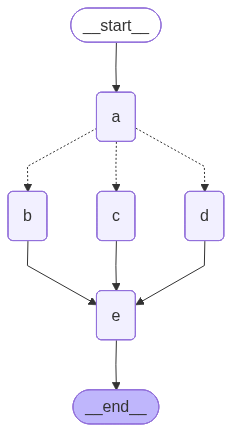

In [15]:
# 그래프 흐름: START → a → {조건부 분기: b,c 또는 c,d} → e → END
# a 노드: route_bc_or_cd 함수가 which 값에 따라 분기 경로를 결정해요
# 조건부 엣지: which="cd"이면 c,d로, 그 외에는 b,c로 동시 Fan-out해요
# e 노드: 모든 중간 노드가 합류하는 공통 종착 노드예요
from IPython.display import Image, display

display(Image(graph5.get_graph().draw_mermaid_png()))

In [16]:
# which='bc': B와 C로 분기해요
# === which='bc' 실행 ===
result_bc = graph5.invoke({"aggregate": [], "which": "bc"})
print("결과:", result_bc["aggregate"])

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm E to ["I'm A", "I'm B", "I'm C"]
결과: ["I'm A", "I'm B", "I'm C", "I'm E"]


In [17]:
# which='cd': C와 D로 분기해요
# === which='cd' 실행 ===
result_cd = graph5.invoke({"aggregate": [], "which": "cd"})
print("결과:", result_cd["aggregate"])

Adding I'm A to []
Adding I'm C to ["I'm A"]
Adding I'm D to ["I'm A"]
Adding I'm E to ["I'm A", "I'm C", "I'm D"]
결과: ["I'm A", "I'm C", "I'm D", "I'm E"]


## 6. 커스텀 리듀서: 신뢰도 기반 집계

병렬 노드의 결과를 단순히 누적하는 것 이상이 필요할 때 **커스텀 리듀서(Custom Reducer)**를 사용해요.

예를 들어, 여러 분석 모델이 병렬로 실행될 때 각 결과에 **신뢰도(reliability)** 점수가 있다면, 가장 신뢰도 높은 결과부터 정렬해서 최종 결론에 반영하고 싶을 수 있어요.

```mermaid
flowchart TD
    A[노드 A<br>분기 결정] --> B[노드 B<br>reliability=0.1]
    A --> C[노드 C<br>reliability=0.9]
    A --> D[노드 D<br>reliability=0.5]
    B --> E[노드 E<br>신뢰도 순 정렬 집계]
    C --> E
    D --> E
    E --> END([끝])

    subgraph FR[fanout_values에 신뢰도 포함]
        B
        C
        D
    end

    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef parallel fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class A process
    class B,C,D parallel
    class E,END output
```

> 🔑 **핵심 개념**: 커스텀 리듀서를 사용하면 `fanout_values`라는 별도 필드에 {값, 신뢰도} 형태로 결과를 모은 뒤, 집계 노드에서 정렬·가공할 수 있어요. 이것이 **Map-Reduce 패턴**의 핵심이에요.

In [18]:
import operator
from typing import Annotated, Any, Sequence
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# ---------------------------------------------------
# 커스텀 리듀서: fanout_values 누적 및 초기화 처리
# ---------------------------------------------------
def reduce_fanouts(left, right):
    """fanout_values를 안전하게 누적해요.
    - left가 None이면 빈 리스트로 초기화
    - right가 비어 있으면 초기화 (덮어쓰기)
    - 그 외에는 두 리스트를 연결해요
    """
    if left is None:
        left = []
    if not right:
        return []  # 빈 값이면 초기화 (집계 후 리셋용)
    return left + right  # 리스트 연결


# ---------------------------------------------------
# 상태: aggregate (최종 결과), fanout_values (중간 집계), which (분기 조건)
# ---------------------------------------------------
class State(TypedDict):
    aggregate: Annotated[list, operator.add]         # 최종 집계 결과
    fanout_values: Annotated[list, reduce_fanouts]   # 병렬 노드의 중간 결과
    which: str


# ---------------------------------------------------
# 병렬 노드: 값과 신뢰도를 함께 반환해요
# ---------------------------------------------------
class ParallelReturnNodeValue:
    def __init__(self, node_secret: str, reliability: float):
        self._value = node_secret
        self._reliability = reliability  # 0.0 ~ 1.0 범위의 신뢰도 점수

    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} (reliability={self._reliability}) to {state['aggregate']}")
        return {
            "fanout_values": [
                {
                    "value": [self._value],
                    "reliability": self._reliability,
                }
            ]
        }


# ---------------------------------------------------
# 그래프 구성
# ---------------------------------------------------
builder = StateGraph(State)

def node_a(state: State) -> Any:
    print(f"A 실행: {state['aggregate']}")
    return {"aggregate": ["I'm A"]}

builder.add_node("a", node_a)
builder.add_edge(START, "a")

# 신뢰도가 서로 다른 세 개의 병렬 노드
builder.add_node("b", ParallelReturnNodeValue("I'm B", reliability=0.1))  # 낮은 신뢰도
builder.add_node("c", ParallelReturnNodeValue("I'm C", reliability=0.9))  # 높은 신뢰도
builder.add_node("d", ParallelReturnNodeValue("I'm D", reliability=0.5))  # 중간 신뢰도


# ---------------------------------------------------
# 집계 노드: 신뢰도 기준으로 내림차순 정렬 후 최종 결과에 반영
# ---------------------------------------------------
def aggregate_fanout_values(state: State) -> Any:
    """fanout_values를 신뢰도 기준으로 정렬하고 aggregate에 추가해요."""
    # 신뢰도(reliability) 기준 내림차순 정렬: 가장 신뢰도 높은 것부터
    ranked_values = sorted(
        state["fanout_values"],
        key=lambda x: x["reliability"],
        reverse=True,  # 내림차순: 높은 신뢰도 먼저
    )
    # 신뢰도 순 정렬 결과:
    for item in ranked_values:
        print(f"  {item['value'][0]}: reliability={item['reliability']}")

    return {
        "aggregate": [x["value"][0] for x in ranked_values] + ["I'm E"],
        "fanout_values": [],  # 사용 후 초기화 (다음 실행을 위해)
    }


builder.add_node("e", aggregate_fanout_values)


# 조건부 분기: which 값에 따라 B,C 또는 C,D로 분기
def route_bc_or_cd(state: State) -> Sequence[str]:
    if state["which"] == "cd":
        return ["c", "d"]
    return ["b", "c"]


intermediates = ["b", "c", "d"]
builder.add_conditional_edges("a", route_bc_or_cd, intermediates)

for node in intermediates:
    builder.add_edge(node, "e")

builder.add_edge("e", END)
graph6 = builder.compile()
# 커스텀 리듀서 그래프 컴파일 완료!

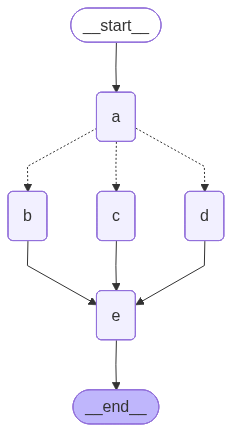

In [19]:
# 그래프 흐름: START → a → {조건부: b,c 또는 c,d} → e(집계) → END
# b, c, d 노드: 각각 다른 신뢰도(reliability)를 가진 병렬 분석 노드예요
# e 노드: fanout_values를 신뢰도 기준 내림차순 정렬 후 aggregate에 추가해요
# 커스텀 리듀서(reduce_fanouts)가 병렬 결과를 안전하게 누적해요
from IPython.display import Image, display

display(Image(graph6.get_graph().draw_mermaid_png()))

In [20]:
# which='bc': B(0.1)와 C(0.9)가 실행돼요 - C가 높은 신뢰도라 먼저 집계돼요
# === which='bc' 실행 (B: 0.1, C: 0.9) ===
result_bc = graph6.invoke({"aggregate": [], "which": "bc", "fanout_values": []})
print("\n최종 aggregate:", result_bc["aggregate"])

A 실행: []
Adding I'm B (reliability=0.1) to ["I'm A"]
Adding I'm C (reliability=0.9) to ["I'm A"]
  I'm C: reliability=0.9
  I'm B: reliability=0.1

최종 aggregate: ["I'm A", "I'm C", "I'm B", "I'm E"]


In [21]:
# which='cd': C(0.9)와 D(0.5)가 실행돼요 - C가 더 높은 신뢰도
# === which='cd' 실행 (C: 0.9, D: 0.5) ===
result_cd = graph6.invoke({"aggregate": [], "which": "cd", "fanout_values": []})
print("\n최종 aggregate:", result_cd["aggregate"])

A 실행: []
Adding I'm C (reliability=0.9) to ["I'm A"]
Adding I'm D (reliability=0.5) to ["I'm A"]
  I'm C: reliability=0.9
  I'm D: reliability=0.5

최종 aggregate: ["I'm A", "I'm C", "I'm D", "I'm E"]


## 최종 실전 예제: LLM 고객지원 티켓 병렬 점검 그래프

앞의 예제는 구조를 보기 쉽게 하려고 작은 문자열과 규칙 기반 라우팅을 사용했어요. 마지막 예제에서는 같은 패턴을 실제 업무에 더 가깝게 바꿔봅니다.

이번 목표는 **LLM이 고객 문의를 읽고 필요한 점검 노드를 여러 개 선택**한 뒤, 선택된 점검 노드들이 병렬로 실행되고, 마지막에 LLM이 답변 초안을 작성하는 그래프를 만드는 거예요.

```mermaid
flowchart TD
    A[고객 문의] --> B[LLM analyze_ticket]
    B --> C{selected_checks}
    C -->|환불/결제| D[refund_policy_check]
    C -->|로그인/오류| E[technical_check]
    C -->|프리미엄/긴급| F[sla_priority_check]
    C -->|일반 문의| G[general_support_check]
    D --> H[LLM draft_customer_reply]
    E --> H
    F --> H
    G --> H
    H --> I[최종 답변]
```

> 🎯 **강의 포인트**: `add_conditional_edges()`가 라우팅 함수의 반환값에 따라 **하나 또는 여러 개의 점검 노드로 fan-out**하고, 각 점검 노드의 `findings`는 reducer로 안전하게 합쳐집니다. 마지막 답변 작성 노드는 일반 엣지로 명시적으로 연결된 공통 fan-in 지점입니다.


### 실행 방법

아래 셀들을 순서대로 실행하세요.

실행 전 `.env`에 `OPENAI_API_KEY`가 준비되어 있어야 합니다. 이 예제는 두 곳에서 LLM을 호출합니다.

1. `analyze_ticket`: 고객 문의를 읽고 병렬로 실행할 점검 노드 목록을 구조화 출력으로 선택합니다.
2. `draft_customer_reply`: 병렬 점검 결과를 바탕으로 고객에게 보낼 답변 초안을 작성합니다.

샘플 실행 후 마지막 셀의 `my_ticket`과 `my_customer_tier`만 바꿔서 직접 테스트할 수 있어요.


### 1단계 — State와 reducer 정의하기

병렬 점검 노드들은 모두 `findings`와 `trace`를 업데이트합니다. 여러 노드가 같은 키를 동시에 업데이트하므로 reducer가 필요해요.

- `collect_findings`: 병렬 점검 결과 리스트를 누적합니다.
- `operator.add`: 실행 흐름 로그(`trace`)를 리스트로 이어 붙입니다.


In [22]:
# ------------------------------------------------------------
# 1단계: import + State/reducer 정의
# ------------------------------------------------------------
import operator
from typing import Annotated, Any, Literal, Sequence
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langgraph.graph import START, END, StateGraph

# .env 파일에서 OPENAI_API_KEY 등을 읽어옵니다.
load_dotenv(".env", override=True)


def collect_findings(left, right):
    """병렬 점검 노드들이 반환한 findings를 하나의 리스트로 누적합니다."""
    if left is None:
        left = []
    if not right:
        return left
    return left + right


class TicketState(TypedDict):
    """고객지원 병렬 점검 그래프의 공유 State"""

    ticket: str                                      # 고객 문의 원문
    customer_tier: str                               # standard / premium / enterprise
    selected_checks: list[str]                       # LLM이 선택한 병렬 점검 노드 목록
    urgency: str                                     # low / normal / high
    route_reason: str                                # LLM 라우팅 근거
    findings: Annotated[list[dict[str, Any]], collect_findings]
    final_reply: str                                 # 고객에게 보낼 최종 답변 초안
    trace: Annotated[list[str], operator.add]         # 실행 흐름 로그


CHECK_NODE_NAMES = [
    "refund_policy_check",
    "technical_check",
    "sla_priority_check",
    "general_support_check",
]


### 2단계 — LLM 라우터 만들기

`analyze_ticket` 노드는 LLM 구조화 출력으로 어떤 점검 노드를 실행할지 결정합니다.

예를 들어 “프리미엄 고객인데 결제가 두 번 됐고 빨리 처리해 주세요” 같은 문의는 `refund_policy_check`와 `sla_priority_check`를 함께 선택할 수 있어요. 이렇게 라우팅 결과가 리스트가 되면 다음 단계에서 조건부 fan-out이 발생합니다.


In [23]:
# ------------------------------------------------------------
# 2단계: LLM 구조화 출력으로 병렬 점검 계획 세우기
# ------------------------------------------------------------
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model


class TicketRoutingPlan(BaseModel):
    """LLM이 반환할 병렬 점검 계획"""

    checks: list[
        Literal[
            "refund_policy_check",
            "technical_check",
            "sla_priority_check",
            "general_support_check",
        ]
    ] = Field(description="이 문의를 처리하기 위해 병렬로 실행할 점검 노드 목록")
    urgency: Literal["low", "normal", "high"] = Field(description="문의 긴급도")
    reason: str = Field(description="점검 노드를 선택한 짧은 근거")


router_model = init_chat_model("openai:gpt-4o-mini", temperature=0)
ticket_router = router_model.with_structured_output(TicketRoutingPlan)


ROUTER_SYSTEM_PROMPT = """당신은 고객지원 티켓 라우터입니다.
고객 문의와 고객 등급을 읽고 필요한 점검 노드를 하나 이상 선택하세요.
여러 조건이 동시에 보이면 여러 노드를 함께 선택해야 합니다.

사용 가능한 점검 노드:
- refund_policy_check: 결제, 환불, 청구, 영수증, 중복 결제, 요금 문제
- technical_check: 로그인, 비밀번호, 인증 메일, 오류, 장애, 기술 문제
- sla_priority_check: premium/enterprise 고객, 긴급/ASAP/장애 영향이 큰 문의
- general_support_check: 위 조건에 해당하지 않는 일반 문의

규칙:
- premium 또는 enterprise 고객의 긴급 문의는 sla_priority_check를 포함하세요.
- 결제/환불과 기술 문제가 함께 있으면 두 점검 노드를 모두 선택하세요.
- 특별한 키워드가 없으면 general_support_check만 선택하세요.
"""


def normalize_checks(checks: list[str]) -> list[str]:
    """LLM 결과를 그래프에 등록된 노드 이름으로 정리합니다."""
    valid = set(CHECK_NODE_NAMES)
    normalized: list[str] = []
    for check in checks:
        if check in valid and check not in normalized:
            normalized.append(check)
    return normalized or ["general_support_check"]


def analyze_ticket(state: TicketState) -> dict[str, Any]:
    """LLM이 문의를 읽고 병렬 점검 계획을 세웁니다."""
    plan = ticket_router.invoke([
        {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
        {
            "role": "user",
            "content": (
                f"고객 등급: {state['customer_tier']}\n"
                f"고객 문의: {state['ticket']}"
            ),
        },
    ])
    selected_checks = normalize_checks(plan.checks)

    return {
        "selected_checks": selected_checks,
        "urgency": plan.urgency,
        "route_reason": plan.reason,
        "trace": [
            "LLM 라우팅: "
            f"checks={selected_checks}, urgency={plan.urgency}, reason={plan.reason}"
        ],
    }


def route_to_checks(state: TicketState) -> Sequence[str]:
    """조건부 엣지가 사용할 라우팅 함수입니다."""
    return state["selected_checks"] or ["general_support_check"]


### 3단계 — 병렬 점검 노드 만들기

각 점검 노드는 서로 독립적으로 실행됩니다. 그래서 같은 superstep에서 병렬로 실행될 수 있고, 결과는 `findings` reducer로 합쳐집니다.

각 finding에는 다음 정보를 담습니다.

- `area`: 어떤 영역의 점검인지
- `priority`: 답변에서 얼마나 우선해야 하는지
- `confidence`: 점검 결과 신뢰도
- `summary`: 고객에게 설명할 핵심 내용
- `action`: 다음 조치


In [24]:
# ------------------------------------------------------------
# 3단계: 병렬 점검 노드 정의
# ------------------------------------------------------------
def refund_policy_check(state: TicketState) -> dict[str, Any]:
    return {
        "findings": [
            {
                "area": "결제/환불",
                "priority": 2,
                "confidence": 0.86,
                "summary": "결제/환불 규정 확인이 필요한 문의입니다.",
                "action": "주문번호, 결제 시각, 결제 수단을 확인한 뒤 환불 가능 여부를 안내합니다.",
            }
        ],
        "trace": ["병렬 점검: 환불 정책 확인"],
    }


def technical_check(state: TicketState) -> dict[str, Any]:
    return {
        "findings": [
            {
                "area": "기술지원",
                "priority": 3,
                "confidence": 0.9,
                "summary": "로그인/인증/오류 흐름에서 기술 점검이 필요합니다.",
                "action": "계정 이메일, 오류 화면, 발생 시각을 받아 인증 로그와 장애 여부를 확인합니다.",
            }
        ],
        "trace": ["병렬 점검: 기술 문제 확인"],
    }


def sla_priority_check(state: TicketState) -> dict[str, Any]:
    return {
        "findings": [
            {
                "area": "우선순위/SLA",
                "priority": 4,
                "confidence": 0.95,
                "summary": "고객 등급 또는 긴급도 때문에 빠른 1차 응답이 필요한 문의입니다.",
                "action": "담당자에게 즉시 배정하고 SLA 타이머를 시작합니다.",
            }
        ],
        "trace": ["병렬 점검: SLA 우선순위 확인"],
    }


def general_support_check(state: TicketState) -> dict[str, Any]:
    return {
        "findings": [
            {
                "area": "일반문의",
                "priority": 1,
                "confidence": 0.75,
                "summary": "전문 점검보다 문의 목적을 더 구체화하는 것이 먼저입니다.",
                "action": "고객에게 원하는 결과와 현재 상황을 한 번 더 확인합니다.",
            }
        ],
        "trace": ["병렬 점검: 일반 문의 확인"],
    }


### 4단계 — LLM 답변 작성 노드와 그래프 조립하기

`draft_customer_reply`는 병렬 점검 결과를 우선순위와 신뢰도 기준으로 정렬한 뒤, LLM에게 고객 답변 초안을 작성하게 합니다.

그래프 조립에서 중요한 부분은 두 가지예요.

1. `add_conditional_edges("analyze_ticket", route_to_checks, CHECK_NODE_NAMES)`로 LLM이 선택한 점검 노드들로 fan-out합니다.
2. 각 점검 노드에서 `draft_customer_reply`로 일반 엣지를 추가해 공통 fan-in 지점을 명시합니다.


In [25]:
# ------------------------------------------------------------
# 4단계: LLM 답변 작성 노드 + 그래프 조립
# ------------------------------------------------------------
reply_model = init_chat_model("openai:gpt-4o-mini", temperature=0)


REPLY_SYSTEM_PROMPT = """당신은 고객지원 상담원입니다.
아래 병렬 점검 결과를 바탕으로 고객에게 보낼 한국어 답변 초안을 작성하세요.

작성 규칙:
- 첫 문장은 문의를 확인했다는 공감 표현으로 시작하세요.
- 가장 priority가 높은 finding을 먼저 반영하세요.
- 고객에게 요청해야 할 정보가 있으면 구체적으로 말하세요.
- 내부 용어(priority, confidence, finding)는 그대로 노출하지 마세요.
- 4문장 이내로 간결하게 작성하세요.
"""


def format_findings(findings: list[dict[str, Any]]) -> str:
    """LLM 프롬프트에 넣기 좋게 findings를 문자열로 정리합니다."""
    ranked = sorted(
        findings,
        key=lambda item: (item["priority"], item["confidence"]),
        reverse=True,
    )
    return "\n".join(
        f"- [{item['area']}] summary={item['summary']} action={item['action']}"
        for item in ranked
    )


def draft_customer_reply(state: TicketState) -> dict[str, Any]:
    """병렬 점검 결과를 모아 LLM 답변 초안을 작성합니다."""
    findings_text = format_findings(state["findings"])
    response = reply_model.invoke([
        {"role": "system", "content": REPLY_SYSTEM_PROMPT},
        {
            "role": "user",
            "content": (
                f"고객 등급: {state['customer_tier']}\n"
                f"긴급도: {state['urgency']}\n"
                f"고객 문의: {state['ticket']}\n\n"
                f"병렬 점검 결과:\n{findings_text}"
            ),
        },
    ])
    reply_text = response.content
    if isinstance(reply_text, list):
        reply_text = "\n".join(str(block) for block in reply_text)

    return {
        "final_reply": reply_text,
        "trace": ["LLM 답변 초안 작성"],
    }


ticket_builder = StateGraph(TicketState)
ticket_builder.add_node("analyze_ticket", analyze_ticket)
ticket_builder.add_node("refund_policy_check", refund_policy_check)
ticket_builder.add_node("technical_check", technical_check)
ticket_builder.add_node("sla_priority_check", sla_priority_check)
ticket_builder.add_node("general_support_check", general_support_check)
ticket_builder.add_node("draft_customer_reply", draft_customer_reply)

ticket_builder.add_edge(START, "analyze_ticket")
ticket_builder.add_conditional_edges(
    "analyze_ticket",
    route_to_checks,
    CHECK_NODE_NAMES,  # path_map: LLM 라우터가 반환할 수 있는 후보 노드 목록
)

# 선택된 병렬 점검 노드가 끝나면 공통 합류 노드에서 답변을 작성합니다.
for check_node in CHECK_NODE_NAMES:
    ticket_builder.add_edge(check_node, "draft_customer_reply")

ticket_builder.add_edge("draft_customer_reply", END)
ticket_graph = ticket_builder.compile()

# LLM 고객지원 병렬 점검 그래프 컴파일 완료!


### 5단계 — 그래프 구조 확인하기

그래프를 시각화하면 `analyze_ticket`에서 여러 점검 노드로 뻗어 나간 뒤, 다시 `draft_customer_reply`로 모이는 구조를 확인할 수 있습니다.


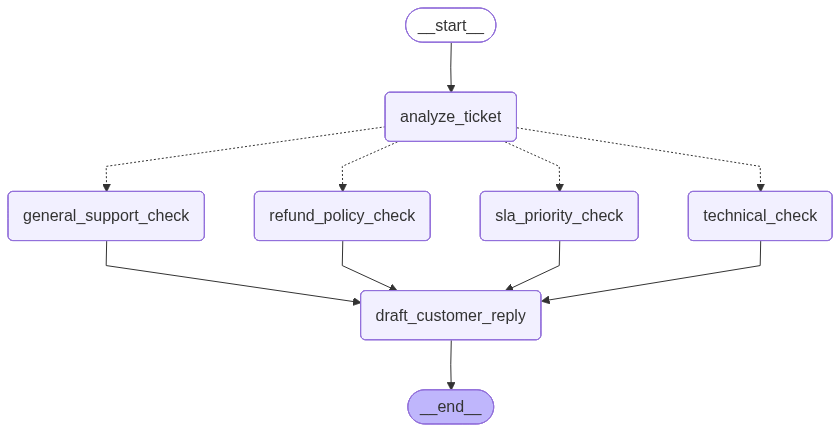

In [26]:
# 그래프 흐름: LLM 라우팅 → 조건부 병렬 점검 → LLM 답변 작성 → END
from IPython.display import Image, display

display(Image(ticket_graph.get_graph().draw_mermaid_png()))


### 6단계 — 샘플 티켓으로 실행 흐름 추적하기

`run_ticket_case()`는 한 건의 티켓을 실행하고, LLM이 선택한 병렬 점검 목록과 최종 답변을 함께 출력합니다.

샘플을 보면 입력 문장에 따라 실행되는 점검 노드 조합이 달라지는 것을 확인할 수 있어요.


In [27]:
# ------------------------------------------------------------
# 6단계: 실행 도우미 함수 + 샘플 티켓 테스트
# ------------------------------------------------------------
def initial_ticket_state(ticket: str, customer_tier: str = "standard") -> TicketState:
    """매 실행마다 새 State를 만듭니다."""
    return {
        "ticket": ticket,
        "customer_tier": customer_tier,
        "selected_checks": [],
        "urgency": "",
        "route_reason": "",
        "findings": [],
        "final_reply": "",
        "trace": [],
    }


def run_ticket_case(ticket: str, customer_tier: str = "standard") -> TicketState:
    """티켓 한 건을 실행하고 학습용으로 핵심 상태를 출력합니다."""
    print("=" * 80)
    print(f"고객 등급: {customer_tier}")
    print(f"고객 문의: {ticket}")

    final_state = ticket_graph.invoke(initial_ticket_state(ticket, customer_tier))

    ranked_findings = sorted(
        final_state["findings"],
        key=lambda item: (item["priority"], item["confidence"]),
        reverse=True,
    )

    print("\n[LLM 라우팅 결과]")
    print("선택된 병렬 점검:", final_state["selected_checks"])
    print("긴급도:", final_state["urgency"])
    print("근거:", final_state["route_reason"])

    print("\n[병렬 점검 결과]")
    for item in ranked_findings:
        print(f"- {item['area']}: {item['summary']}")

    print("\n[최종 답변 초안]")
    print(final_state["final_reply"])

    print("\n[Trace]")
    print(" → ".join(final_state["trace"]))
    return final_state


sample_tickets = [
    {
        "ticket": "프리미엄 고객입니다. 카드에서 같은 금액이 두 번 빠져나갔고 빨리 환불받고 싶어요.",
        "customer_tier": "premium",
    },
    {
        "ticket": "로그인이 안 되고 비밀번호 재설정 메일도 오지 않습니다.",
        "customer_tier": "standard",
    },
]

for sample in sample_tickets:
    run_ticket_case(**sample)
    print()


고객 등급: premium
고객 문의: 프리미엄 고객입니다. 카드에서 같은 금액이 두 번 빠져나갔고 빨리 환불받고 싶어요.

[LLM 라우팅 결과]
선택된 병렬 점검: ['refund_policy_check', 'sla_priority_check']
긴급도: high
근거: 프리미엄 고객의 긴급 환불 요청

[병렬 점검 결과]
- 우선순위/SLA: 고객 등급 또는 긴급도 때문에 빠른 1차 응답이 필요한 문의입니다.
- 결제/환불: 결제/환불 규정 확인이 필요한 문의입니다.

[최종 답변 초안]
문의하신 내용을 확인했습니다. 카드에서 같은 금액이 두 번 빠져나간 경우, 환불 가능 여부를 확인하기 위해 주문번호, 결제 시각, 결제 수단을 알려주시면 감사하겠습니다. 빠른 처리를 위해 즉시 담당자에게 전달하겠습니다.

[Trace]
LLM 라우팅: checks=['refund_policy_check', 'sla_priority_check'], urgency=high, reason=프리미엄 고객의 긴급 환불 요청 → 병렬 점검: 환불 정책 확인 → 병렬 점검: SLA 우선순위 확인 → LLM 답변 초안 작성

고객 등급: standard
고객 문의: 로그인이 안 되고 비밀번호 재설정 메일도 오지 않습니다.

[LLM 라우팅 결과]
선택된 병렬 점검: ['technical_check']
긴급도: normal
근거: 고객이 로그인 문제와 비밀번호 재설정 메일 미수신 문제를 보고했습니다.

[병렬 점검 결과]
- 기술지원: 로그인/인증/오류 흐름에서 기술 점검이 필요합니다.

[최종 답변 초안]
고객님, 문의 주셔서 감사합니다. 현재 로그인 및 인증 과정에서 기술 점검이 필요하여, 계정 이메일과 오류 화면, 발생 시각을 알려주시면 문제를 확인하는 데 큰 도움이 됩니다. 추가 정보를 제공해 주시면 신속하게 도와드리겠습니다.

[Trace]
LLM 라우팅: checks=['technical_check'], urgency=normal, reason=고객이 로그인 문제와 비밀번호 

### 7단계 — 직접 티켓을 바꿔 실행하기

마지막으로 `my_ticket`과 `my_customer_tier`만 바꿔서 실행해 보세요. LLM 라우터가 어떤 병렬 점검 노드를 선택하는지 확인하는 것이 핵심입니다.


In [28]:
# ------------------------------------------------------------
# 7단계: 직접 티켓을 바꿔 실행하기
# ------------------------------------------------------------
my_ticket = "엔터프라이즈 고객입니다. 로그인 장애 때문에 팀 전체가 서비스를 못 쓰고 있어요. 긴급합니다."
my_customer_tier = "enterprise"

run_ticket_case(my_ticket, my_customer_tier)


고객 등급: enterprise
고객 문의: 엔터프라이즈 고객입니다. 로그인 장애 때문에 팀 전체가 서비스를 못 쓰고 있어요. 긴급합니다.

[LLM 라우팅 결과]
선택된 병렬 점검: ['sla_priority_check', 'technical_check']
긴급도: high
근거: 엔터프라이즈 고객의 긴급 로그인 장애 문의

[병렬 점검 결과]
- 우선순위/SLA: 고객 등급 또는 긴급도 때문에 빠른 1차 응답이 필요한 문의입니다.
- 기술지원: 로그인/인증/오류 흐름에서 기술 점검이 필요합니다.

[최종 답변 초안]
문의하신 내용을 확인했습니다. 로그인 장애로 인해 팀 전체가 서비스를 이용하지 못하고 계신 점 매우 안타깝습니다. 문제 해결을 위해 계정 이메일, 오류 화면의 스크린샷, 그리고 장애가 발생한 시각을 알려주시면 감사하겠습니다. 신속하게 확인하여 조치를 취하겠습니다.

[Trace]
LLM 라우팅: checks=['sla_priority_check', 'technical_check'], urgency=high, reason=엔터프라이즈 고객의 긴급 로그인 장애 문의 → 병렬 점검: SLA 우선순위 확인 → 병렬 점검: 기술 문제 확인 → LLM 답변 초안 작성


{'ticket': '엔터프라이즈 고객입니다. 로그인 장애 때문에 팀 전체가 서비스를 못 쓰고 있어요. 긴급합니다.',
 'customer_tier': 'enterprise',
 'selected_checks': ['sla_priority_check', 'technical_check'],
 'urgency': 'high',
 'route_reason': '엔터프라이즈 고객의 긴급 로그인 장애 문의',
 'findings': [{'area': '우선순위/SLA',
   'priority': 4,
   'confidence': 0.95,
   'summary': '고객 등급 또는 긴급도 때문에 빠른 1차 응답이 필요한 문의입니다.',
   'action': '담당자에게 즉시 배정하고 SLA 타이머를 시작합니다.'},
  {'area': '기술지원',
   'priority': 3,
   'confidence': 0.9,
   'summary': '로그인/인증/오류 흐름에서 기술 점검이 필요합니다.',
   'action': '계정 이메일, 오류 화면, 발생 시각을 받아 인증 로그와 장애 여부를 확인합니다.'}],
 'final_reply': '문의하신 내용을 확인했습니다. 로그인 장애로 인해 팀 전체가 서비스를 이용하지 못하고 계신 점 매우 안타깝습니다. 문제 해결을 위해 계정 이메일, 오류 화면의 스크린샷, 그리고 장애가 발생한 시각을 알려주시면 감사하겠습니다. 신속하게 확인하여 조치를 취하겠습니다.',
 'trace': ["LLM 라우팅: checks=['sla_priority_check', 'technical_check'], urgency=high, reason=엔터프라이즈 고객의 긴급 로그인 장애 문의",
  '병렬 점검: SLA 우선순위 확인',
  '병렬 점검: 기술 문제 확인',
  'LLM 답변 초안 작성']}

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **Fan-out / Fan-in**: `add_edge("a", "b")` + `add_edge("a", "c")`로 분기하고, `add_edge(["b", "c"], "d")`로 합쳐요
- **Annotated[list, operator.add]**: 병렬 노드가 같은 키에 쓸 때 덮어쓰지 않고 리스트를 안전하게 누적해요
- **ReturnNodeValue 클래스 패턴**: 노드 로직을 클래스로 캡슐화해 서로 다른 값을 주입할 수 있어요
- **defer=True**: 모든 선행 작업을 자동으로 기다려 복잡한 의존성을 간단하게 처리해요
- **Superstep 트랜잭션**: 병렬 분기 중 하나라도 실패하면 전체 superstep이 롤백돼요
- **add_conditional_edges()**: 라우팅 함수가 `Sequence[str]`을 반환해 런타임에 동적으로 분기해요
- **path_map/가능한 분기 목록**: `add_conditional_edges("a", route, ["b", "c", "d"])`처럼 후보를 명시하면 구조가 명확하고 시각화가 정확해져요
- **공통 합류 노드**: 조건부 분기 뒤의 sink 노드는 `for node in intermediates: add_edge(node, "e")`처럼 명시적으로 연결해요
- **커스텀 리듀서**: `reduce_fanouts` 같은 함수로 복잡한 병합 로직을 구현할 수 있어요
- **최종 실전 예제**: LLM이 고객지원 티켓을 읽고 필요한 병렬 점검 노드를 선택한 뒤, reducer로 결과를 모아 LLM 답변 초안을 작성하는 흐름을 구현했어요

### 패턴 비교표

| 패턴 | 사용 시점 | 핵심 API |
|------|-----------|----------|
| 기본 Fan-out/Fan-in | 경로가 미리 정해진 병렬 처리 | `add_edge` |
| 다단계 경로 | 병렬 경로 내에 순차 단계 존재 | `add_edge([list], node)` |
| defer=True | 복잡한 의존성, map-reduce | `add_node(..., defer=True)` |
| 조건부 분기 | 런타임 상태에 따른 동적 분기 | `add_conditional_edges` |
| 조건부 분기 + 공통 합류 | 동적 분기 후 반드시 공통 집계 노드 실행 | `add_conditional_edges` + `add_edge` |
| LLM 라우팅 + 병렬 점검 | 자연어 입력에서 여러 점검 노드를 동적으로 선택 | `init_chat_model` + `add_conditional_edges` |
| 커스텀 리듀서 | 결과 정렬, 가중치 집계 | `Annotated[list, custom_fn]` |


## 다음 노트북 예고

다음 `04-Durable-Execution.ipynb`에서는 **내구성 실행(Durable Execution)**을 배워요. 체크포인터를 활용해 그래프 실행 도중 장애가 발생해도 중단 지점부터 재개하는 방법, 그리고 retry 정책으로 실패한 노드를 자동으로 재시도하는 방법을 살펴볼 거예요. 오늘 배운 병렬 실행 패턴에 내구성을 더하면 프로덕션에 배포할 수 있는 견고한 그래프를 만들 수 있어요!